### LSTM for prediction of angles

### Imports

In [1]:
import os
import glob
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import time
import joblib
import json

In [2]:
name = "7015701_epochs_optunafullBIEN" 
BASE_DIR = r"C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/RNN"
RESULTS_DIR = os.path.join(BASE_DIR, "LSTMact7fullBIEN_angle", name) #para crear una carpeta con el nombre del experimento dentro de la carpeta de resultados
PTH_DIR = os.path.join(BASE_DIR, "LSTMpth", f"best_emg_model_seq_LSTM_{name}.pth")  #para guardar el modelo entrenado con el nombre del experimento dentro de la carpeta de modelos
RESULTS_LSTM_DIR = os.path.join(BASE_DIR, "LSTMact7fullBIEN_angle", name)

os.makedirs(os.path.dirname(PTH_DIR), exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
DATA_PTH = r"C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes"

nota = """
Experimento LSTM - 7015701_epochs_optunafullBIEN

- Datos: sim_data_MATSUOKA6_sinsconethingsBIEN
- input_len=60, output_len=30, hidden_dim=35, num_layers=1, dropout= 0.498795757101652
- Optimizer: Adam, lr=0.0005, batch_size=16, epochs=70, patience=10
- Descripción: se ha cambiado la configuración de 80 10 10 a 70 15 15 para el entrenamiento, validación y test respectivamente.
"""

with open(os.path.join(RESULTS_DIR, "nota.txt"), "w", encoding="utf-8") as f:
    f.write(nota)

### Configuración

In [3]:
# ---------- CONFIGURACIÓN ----------
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
torch.backends.cudnn.benchmark = True  
torch.backends.cudnn.deterministic = True  
torch.manual_seed(42)  
if device.type == 'cuda':
    torch.cuda.manual_seed(42)  
    print("Usando GPU") 

input_len = 60  # 1 segundo a 60 Hz
output_len = 30
sequence_len = input_len + output_len
batch_size = 16  

data_path = DATA_PTH
csv_files = glob.glob(
    os.path.join(DATA_PTH, "*_subject_01_cond_ASS-PRE-EXT-*_run*_ecr_fcr_final_recortado.csv")
)
csv_files = sorted(csv_files)

Usando dispositivo: cpu


### División de inputs y outputs

In [4]:

input_signals = []
output_signals = []
input_scalers = []
output_scalers = []

samples_to_remove = int(8 * 60)  # 8 segundos a 60 Hz

for file in csv_files:
    df = pd.read_csv(file)

    if "wrist_hand_r3_pos" in df.columns:
      
        df = df.iloc[samples_to_remove:].reset_index(drop=True)

        input_signal = df["wrist_hand_r3_pos"].values.astype(np.float32)
        # El output ahora es la misma señal de ángulos, dimensionada a (N, 1)
        angle_output = input_signal.reshape(-1, 1)

        input_signals.append(input_signal)
        output_signals.append(angle_output)

indices = np.arange(len(input_signals))
train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, random_state=42)

# Asignación manual de índices


# Divide the signals based on training indices
input_signals_train = [input_signals[i] for i in train_idx]
output_signals_train = [output_signals[i] for i in train_idx]

# Concatenate all training signals.
all_train_inputs = np.concatenate([signal[80:].reshape(-1, 1) for signal in input_signals_train])
all_train_outputs = np.concatenate([signal[80:] for signal in output_signals_train])

scaler_input = MinMaxScaler()
scaler_output = MinMaxScaler()

scaler_input.fit(all_train_inputs)
scaler_output.fit(all_train_outputs)

print("input_len:", input_len)
print("output_len:", output_len)
print("sequence_len:", sequence_len)
print("input_len + output_len =", input_len + output_len)

# Lista completa indexada con ruta completa
for i, fpath in enumerate(csv_files):
    print(f"[{i:02d}] {fpath}")

input_len: 60
output_len: 30
sequence_len: 90
input_len + output_len = 90
[00] C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes\20260305_subject_01_cond_ASS-PRE-EXT-LEFT_run02_ecr_fcr_final_recortado.csv
[01] C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes\20260305_subject_01_cond_ASS-PRE-EXT-LEFT_run03_ecr_fcr_final_recortado.csv
[02] C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes\20260305_subject_01_cond_ASS-PRE-EXT-LEFT_run04_ecr_fcr_final_recortado.csv
[03] C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes\20260305_subject_01_cond_ASS-PRE-EXT-RIGHT_run01_ecr_fcr_final_recortado.csv
[04] C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes\20260305_subject_01_cond_ASS-PRE-EXT-RIGHT_run02_ecr_fcr_final_recortado.csv
[05] C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/R

### Create sequences

In [5]:
def create_sequences(indices): 
    X, y = [], []
    meta = []

    for idx in indices:
        input_seq = input_signals[idx][80:]
        output_seq = output_signals[idx][80:]
        
        if len(input_seq) < sequence_len:
            print(f"Simulation {idx} skipped: insufficient timesteps (has {len(input_seq)}, needs {sequence_len})")
            continue

        input_scaled = scaler_input.transform(input_seq.reshape(-1, 1)).flatten()
        output_scaled = scaler_output.transform(output_seq)
        
        for i in range(len(input_scaled) - sequence_len + 1):
            X.append(input_scaled[i:i+input_len])
            y.append(output_scaled[i+input_len:i+input_len+output_len])
            meta.append((idx, i))
            
    return np.array(X), np.array(y), meta

# saving the scalers
joblib.dump(scaler_input, "scaler_input.pkl")
joblib.dump(scaler_output, "scaler_output.pkl")
# loading the scalers
scaler_input = joblib.load("scaler_input.pkl")
scaler_output = joblib.load("scaler_output.pkl")

X_train, y_train, meta_train = create_sequences(train_idx)
X_val, y_val, meta_val = create_sequences(val_idx)
X_test, y_test, meta_test = create_sequences(test_idx) 

### Dataset

In [6]:
class EMGDataset(Dataset):
    def __init__(self, X, y, scalers=None):
        self.X = torch.tensor(X).unsqueeze(-1).float()
        self.y = torch.tensor(y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(EMGDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(EMGDataset(X_val, y_val), batch_size=batch_size)
test_loader = DataLoader(EMGDataset(X_test, y_test), batch_size=batch_size) 

### LSTM model

In [8]:
class SeqLSTMModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=35, output_dim=1, num_layers=1, dropout_prob=0.498795757101652):
        super(SeqLSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout_prob)
        # Map the last hidden state to (output_len * output_dim) total outputs
        self.fc = nn.Linear(hidden_dim, output_len * output_dim)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        # x: (batch_size, input_len, 1)
        _, (hidden, _) = self.lstm(x)         # hidden: (num_layers, batch_size, hidden_dim)
        hidden_last = hidden[-1]              # (batch_size, hidden_dim)
        hidden_last = self.dropout(hidden_last)
        out = self.fc(hidden_last)            # (batch_size, output_len * output_dim)
        out = out.view(-1, output_len, 1)       # (batch_size, output_len, 1)
        return out

model = SeqLSTMModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.MSELoss()

#overlap entre índices . COMPROBACIONES
print("Train indices:", train_idx)
print("Validation indices:", val_idx)
print("Test indices:", test_idx)

c:\Users\adria\anaconda3\envs\GPU\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.498795757101652 and num_layers=1
  warnings.warn(


Train indices: [ 5  2  1 11  4  7  3  6]
Validation indices: [10  0]
Test indices: [9 8]


### Entrenamiento

In [9]:
# ---------- ENTRENAMIENTO ----------
patience = 10
counter = 0
best_val_loss = float('inf')

train_losses = []
val_losses = []

start_time = time.time()
for epoch in range(120):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        pred = model(batch_X)
        loss = criterion(pred, batch_y)
        optimizer.zero_grad()


        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for val_X, val_y in val_loader:
            val_X, val_y = val_X.to(device), val_y.to(device)
            val_pred = model(val_X)
            val_loss += criterion(val_pred, val_y).item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss) #para guardar la pérdida de validación

    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Batch Loss = {loss.item():.4f}")

    # Visualization of predictions for debugging
    #plt.plot(batch_y[0].cpu().numpy(), label="True")  # Replace y_batch with batch_y
    #plt.plot(pred[0].detach().cpu().numpy(), label="Predicted")
    #plt.legend()
    #plt.show()

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), PTH_DIR)
        print("✅ Modelo guardado")
        counter = 0
         # Guarda la mejor epoch cada vez que mejora
        with open(os.path.join(RESULTS_DIR, "early_stopping_epoch.txt"), "w") as f:
            f.write(str(epoch + 1))  # +1 para que sea 1-based
    else:
        counter += 1
        if counter >= patience:
            print("⏳ Early stopping")
            end_time = time.time()
            elapsed_time = end_time - start_time
            print(f"⏱️ Tiempo de entrenamiento: {elapsed_time:.2f} segundos")
            with open(os.path.join(RESULTS_DIR, "training_time.txt"), "w") as f:
                f.write(f"Training time (s): {elapsed_time:.2f}")
            break

Epoch 1: Train Loss = 0.0335, Val Loss = 0.0318, Batch Loss = 0.0076
✅ Modelo guardado
Epoch 2: Train Loss = 0.0132, Val Loss = 0.0276, Batch Loss = 0.0106
✅ Modelo guardado
Epoch 3: Train Loss = 0.0097, Val Loss = 0.0240, Batch Loss = 0.0119
✅ Modelo guardado
Epoch 4: Train Loss = 0.0081, Val Loss = 0.0222, Batch Loss = 0.0033
✅ Modelo guardado
Epoch 5: Train Loss = 0.0075, Val Loss = 0.0231, Batch Loss = 0.0116
Epoch 6: Train Loss = 0.0072, Val Loss = 0.0207, Batch Loss = 0.0022
✅ Modelo guardado
Epoch 7: Train Loss = 0.0070, Val Loss = 0.0203, Batch Loss = 0.0152
✅ Modelo guardado
Epoch 8: Train Loss = 0.0070, Val Loss = 0.0217, Batch Loss = 0.0074
Epoch 9: Train Loss = 0.0069, Val Loss = 0.0212, Batch Loss = 0.0018
Epoch 10: Train Loss = 0.0068, Val Loss = 0.0190, Batch Loss = 0.0077
✅ Modelo guardado
Epoch 11: Train Loss = 0.0068, Val Loss = 0.0193, Batch Loss = 0.0104
Epoch 12: Train Loss = 0.0068, Val Loss = 0.0195, Batch Loss = 0.0002
Epoch 13: Train Loss = 0.0067, Val Loss = 0

### Learning curves

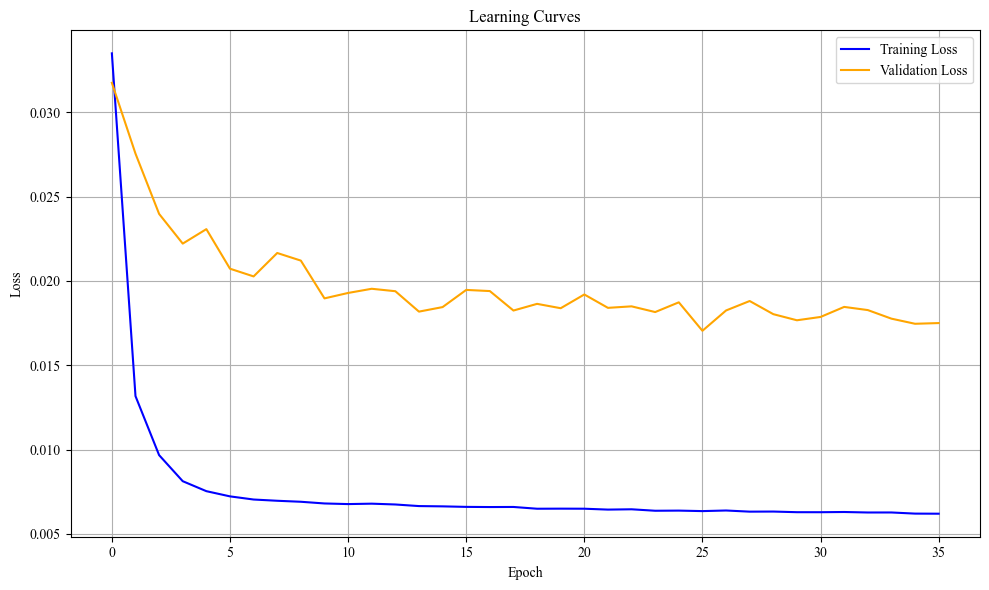

In [21]:
import matplotlib as mpl #para configurar los gráficos
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 10
np.save(os.path.join(RESULTS_DIR, f"train_losses_{name}.npy"), np.array(train_losses))
np.save(os.path.join(RESULTS_DIR, f"val_losses_{name}.npy"), np.array(val_losses))

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="orange")
plt.title("Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f"learning_curve_{name}.png"))
plt.show() 

### Evalucación

C:\Users\adria\AppData\Local\Temp\ipykernel_46400\2890767941.py:88: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(PTH_DIR))



📊 Test Prediction (NORMALIZED):
MAE: 0.0945, RMSE: 0.1334, R²: 0.6418
Correlation (normalized) Angle: 0.8011

📊 Test Angle Prediction:
MAE: 0.9391, RMSE: 1.3252, R²: 0.6418
Correlation (normalized) Angle: 0.8011


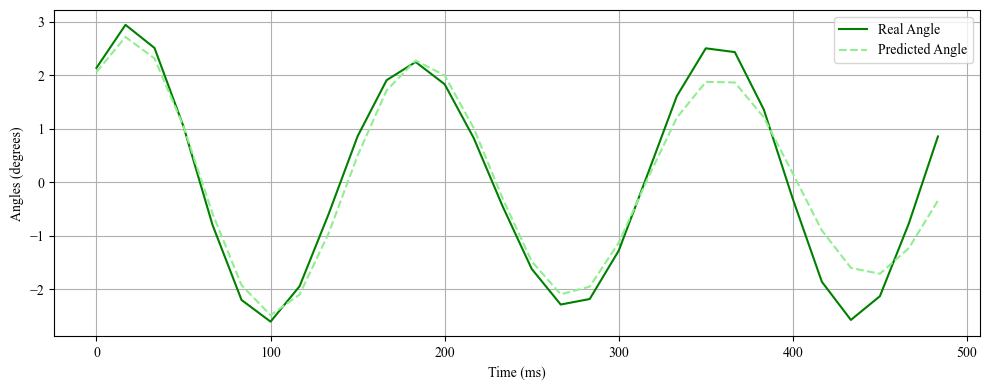

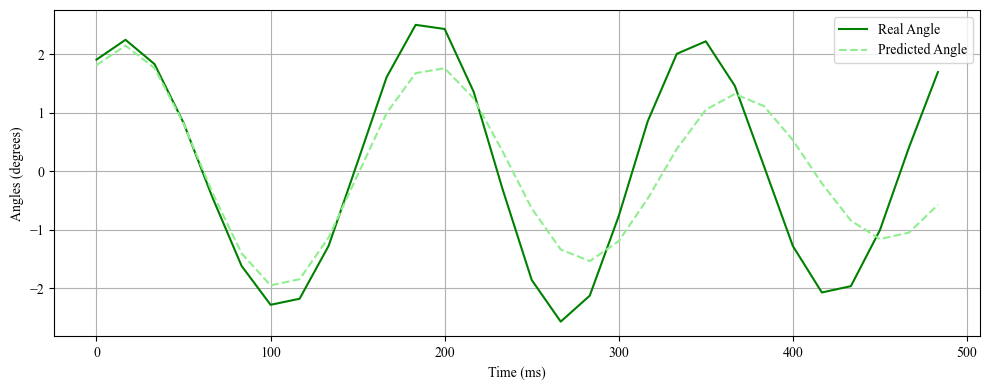

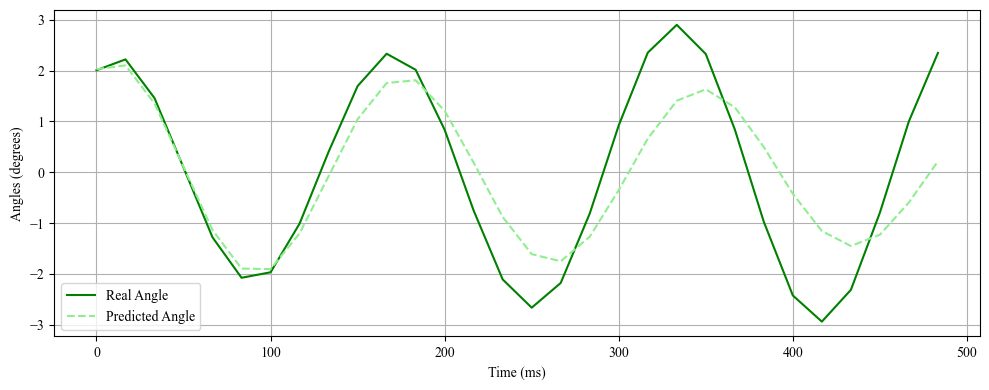

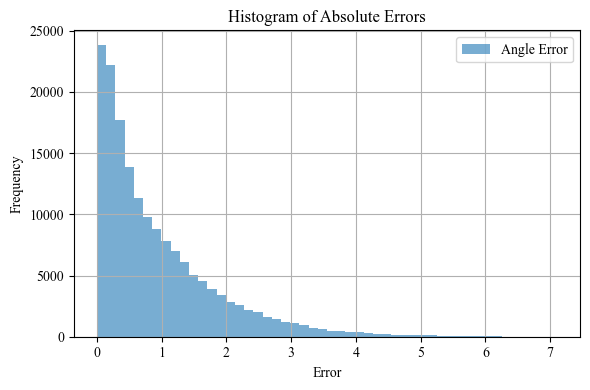


📊 Train Prediction (NORMALIZED):
MAE: 0.0463, RMSE: 0.0733, R²: 0.7366
Correlation (normalized) Angle: 0.8619

📊 Train Angle Prediction:
MAE: 0.4599, RMSE: 0.7284, R²: 0.7366
Correlation (normalized) Angle: 0.8619


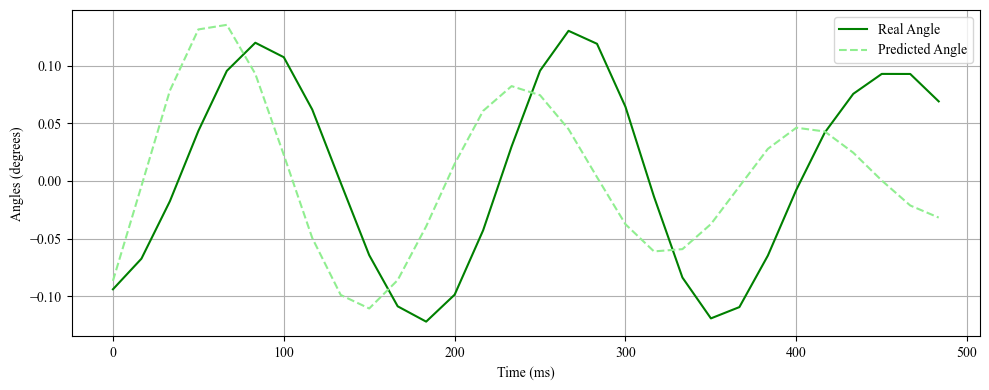

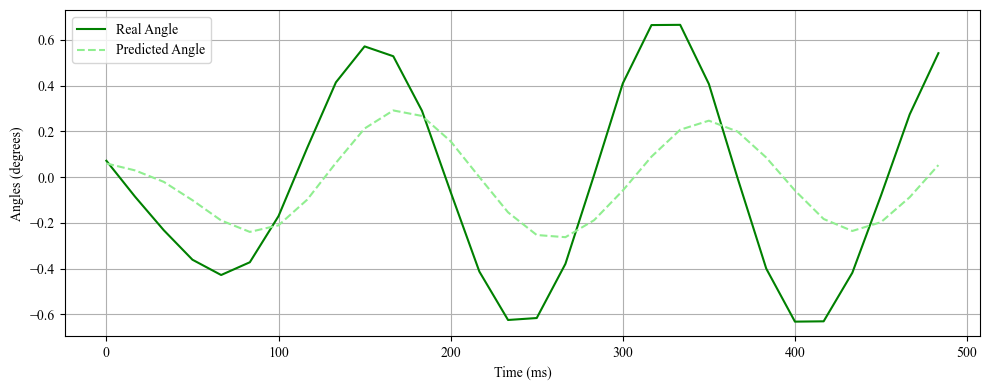

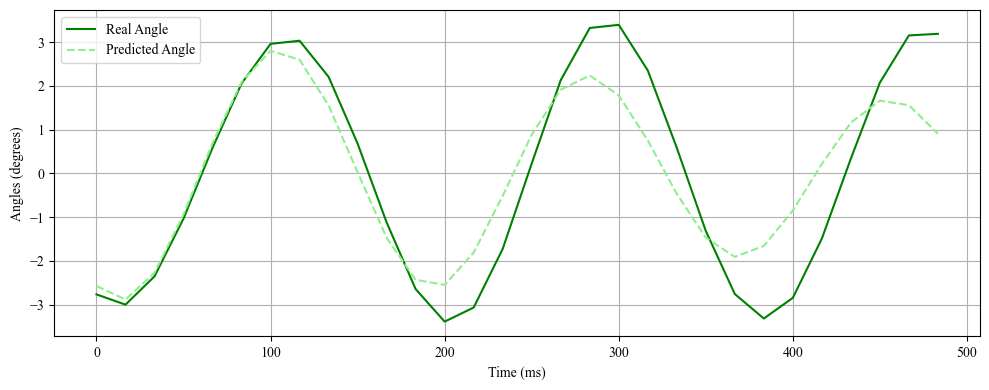

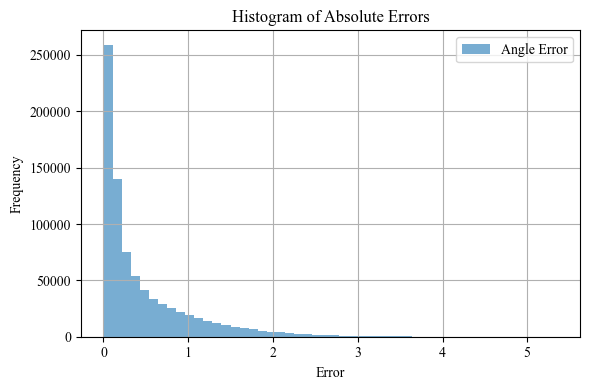


📊 Validation Prediction (NORMALIZED):
MAE: 0.0891, RMSE: 0.1305, R²: 0.7147
Correlation (normalized) Angle: 0.8470

📊 Validation Angle Prediction:
MAE: 0.8857, RMSE: 1.2967, R²: 0.7147
Correlation (normalized) Angle: 0.8470


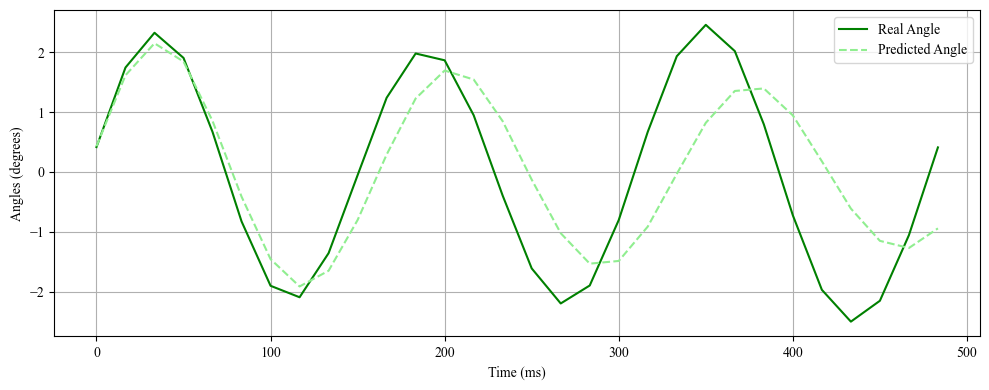

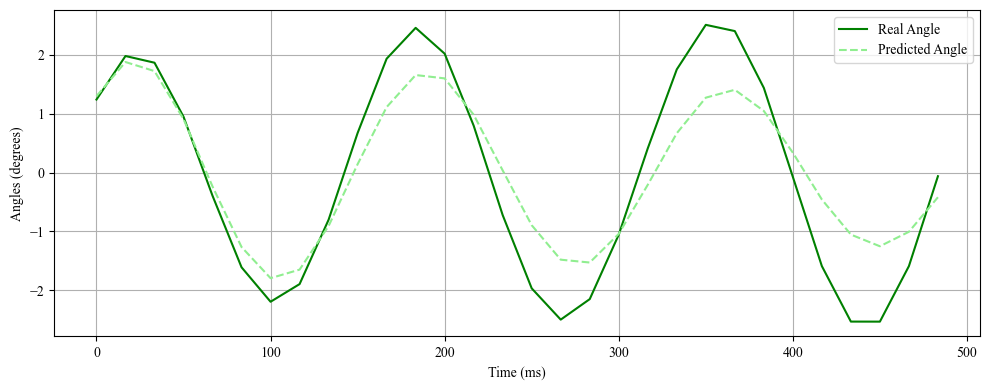

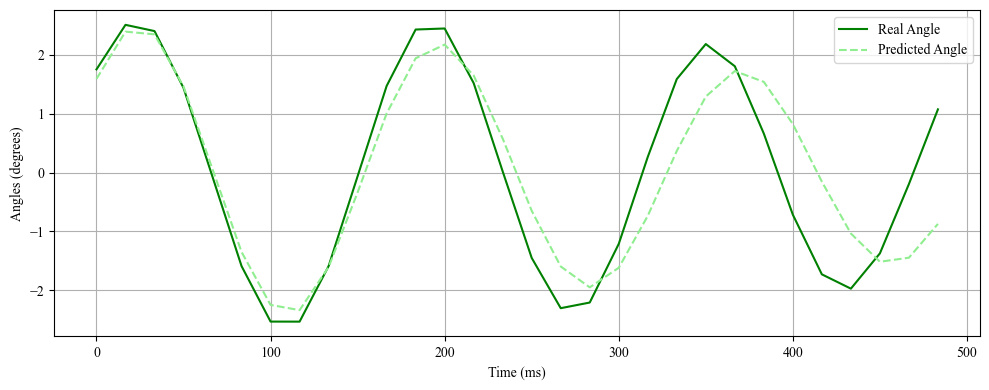

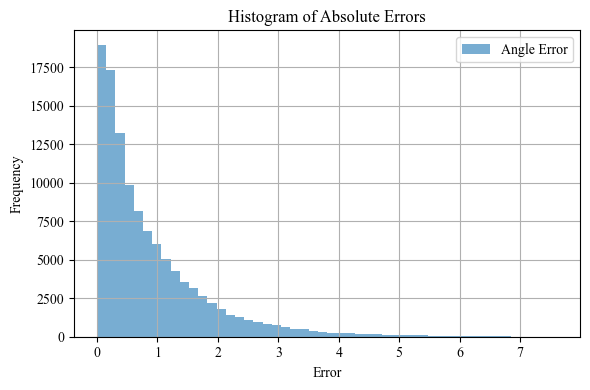

In [22]:

# ---------- EVALUACIÓN ----------
def evaluate_and_plot(loader, title="Evaluación"):
    model.eval()
    all_preds, all_trues = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            all_preds.append(pred.cpu().numpy())
            all_trues.append(y_batch.cpu().numpy())


    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_trues)

    # Reshape a 1 dimensión por timestep
    flat_pred = y_pred.reshape(-1, 1)
    flat_true = y_true.reshape(-1, 1)

    # Métricas
    mae = mean_absolute_error(flat_true, flat_pred)
    rmse = np.sqrt(mean_squared_error(flat_true, flat_pred))
    r2 = r2_score(flat_true, flat_pred)

    corr_ang = np.corrcoef(flat_true[:, 0], flat_pred[:, 0])[0, 1]


    print(f"\n📊 {title} Prediction (NORMALIZED):")
    print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")
    print(f"Correlation (normalized) Angle: {corr_ang:.4f}")
 

    pred_inv = scaler_output.inverse_transform(flat_pred)
    true_inv = scaler_output.inverse_transform(flat_true)

    mae = mean_absolute_error(true_inv, pred_inv)
    rmse = np.sqrt(mean_squared_error(true_inv, pred_inv))
    r2 = r2_score(true_inv, pred_inv)

    corr_m1 = np.corrcoef(true_inv[:, 0].flatten(), pred_inv[:, 0].flatten())[0, 1]

    print(f"\n📊 {title} Angle Prediction:")
    print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")
    print(f"Correlation (normalized) Angle: {corr_m1:.4f}")

    def plot_example(i):
        # Volvemos a la forma (secuencias, timesteps, 1) para plotear
        pred_inv_reshaped = pred_inv.reshape(-1, output_len, 1)
        true_inv_reshaped = true_inv.reshape(-1, output_len, 1)
        
        y_real = true_inv_reshaped[i]
        y_pred_plot = pred_inv_reshaped[i]

        t = np.arange(output_len) * (1000 / 60)  

        plt.figure(figsize=(10, 4))
        plt.plot(t, y_real[:, 0], label='Real Angle', color='green')
        plt.plot(t, y_pred_plot[:, 0], '--', label='Predicted Angle', color='lightgreen')
        plt.xlabel("Time (ms)")
        plt.ylabel("Angles (degrees)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    for i in [0, 10, 30]:
        if i < (len(true_inv) // output_len):
            plot_example(i)

    # Histograma de errores
    pred_inv_reshaped = pred_inv.reshape(-1, output_len, 1)
    true_inv_reshaped = true_inv.reshape(-1, output_len, 1)
    errors = np.abs(pred_inv_reshaped - true_inv_reshaped)

    plt.figure(figsize=(6, 4))
    plt.hist(errors[:, :, 0].flatten(), bins=50, alpha=0.6, label="Angle Error")
    plt.title("Histogram of Absolute Errors")
    plt.xlabel("Error")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return y_pred, y_true

model.load_state_dict(torch.load(PTH_DIR))
y_pred_test, y_true_test = evaluate_and_plot(test_loader, "Test") 
y_pred_train, y_true_train = evaluate_and_plot(train_loader, "Train") 
y_pred_val, y_true_val = evaluate_and_plot(val_loader, "Validation") 

### Gráfica

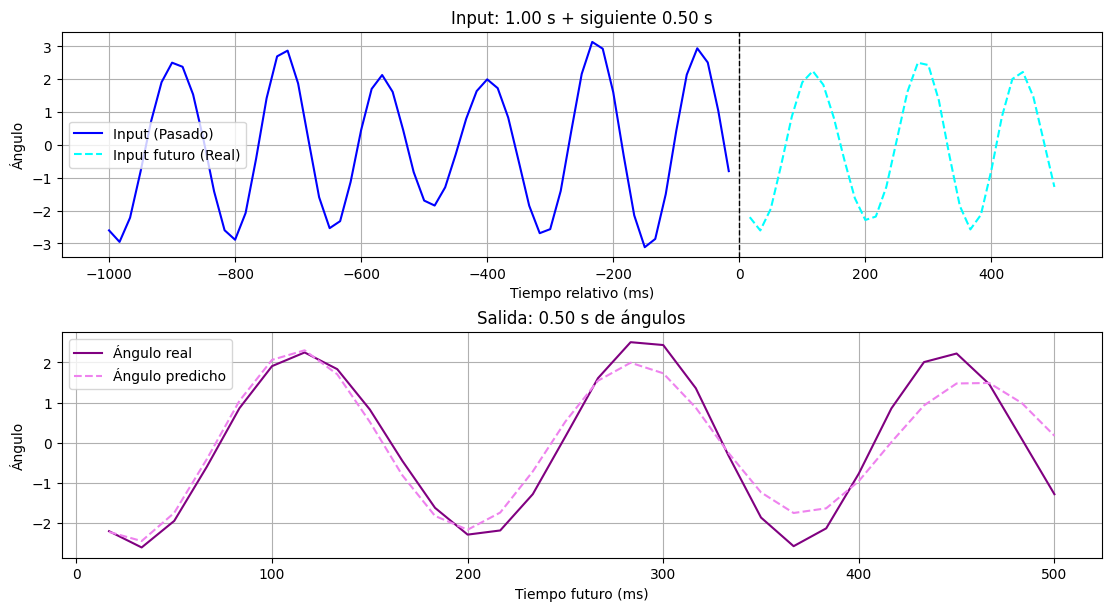

In [ ]:
def plot_input_output_example(sample_idx=0, input_seconds=1.0, output_seconds=0.5):
    fs = 60  # Hz

    input_n = int(input_seconds * fs)
    output_n = int(output_seconds * fs)

    input_n = min(input_n, input_len)
    output_n = min(output_n, output_len)

    signal_idx, start_idx = meta_test[sample_idx]

    full_input = input_signals[signal_idx][80:]
    full_input_window = full_input[start_idx:start_idx + input_len + output_len]

    input_real = full_input_window[:input_len].flatten()
    future_input_real = full_input_window[input_len:input_len + output_n].flatten()

    
    pred_angle = scaler_output.inverse_transform(y_pred_test[sample_idx].reshape(-1, 1))
    true_angle = scaler_output.inverse_transform(y_true_test[sample_idx].reshape(-1, 1))

    t_input = np.arange(-input_n, 0) * (1000 / fs)
    t_future_input = np.arange(1, output_n + 1) * (1000 / fs)
    t_output = np.arange(1, output_n + 1) * (1000 / fs)

    fig, axes = plt.subplots(2, 1, figsize=(11, 6), constrained_layout=True)

    axes[0].plot(t_input, input_real[-input_n:], color="blue", linewidth=1.5, label="Input (Pasado)")
    axes[0].plot(t_future_input, future_input_real[:output_n], color="cyan", linewidth=1.5, linestyle="--", label="Input futuro (Real)")
    axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[0].set_title(f"Input: {input_seconds:.2f} s + siguiente {output_seconds:.2f} s")
    axes[0].set_xlabel("Tiempo relativo (ms)")
    axes[0].set_ylabel("Ángulo")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(t_output, true_angle[:output_n, 0], label="Ángulo real", color="purple")
    axes[1].plot(t_output, pred_angle[:output_n, 0], "--", label="Ángulo predicho", color="violet")
    axes[1].set_title(f"Salida: {output_seconds:.2f} s de ángulos")
    axes[1].set_xlabel("Tiempo futuro (ms)")
    axes[1].set_ylabel("Ángulo")
    axes[1].legend()
    axes[1].grid(True)

    plt.show()

# Probamos la función con la corrección
plot_input_output_example(sample_idx=5, input_seconds=1, output_seconds=0.5)

len(meta_test): 5542
len(y_pred_test): 5542
len(y_true_test): 5542


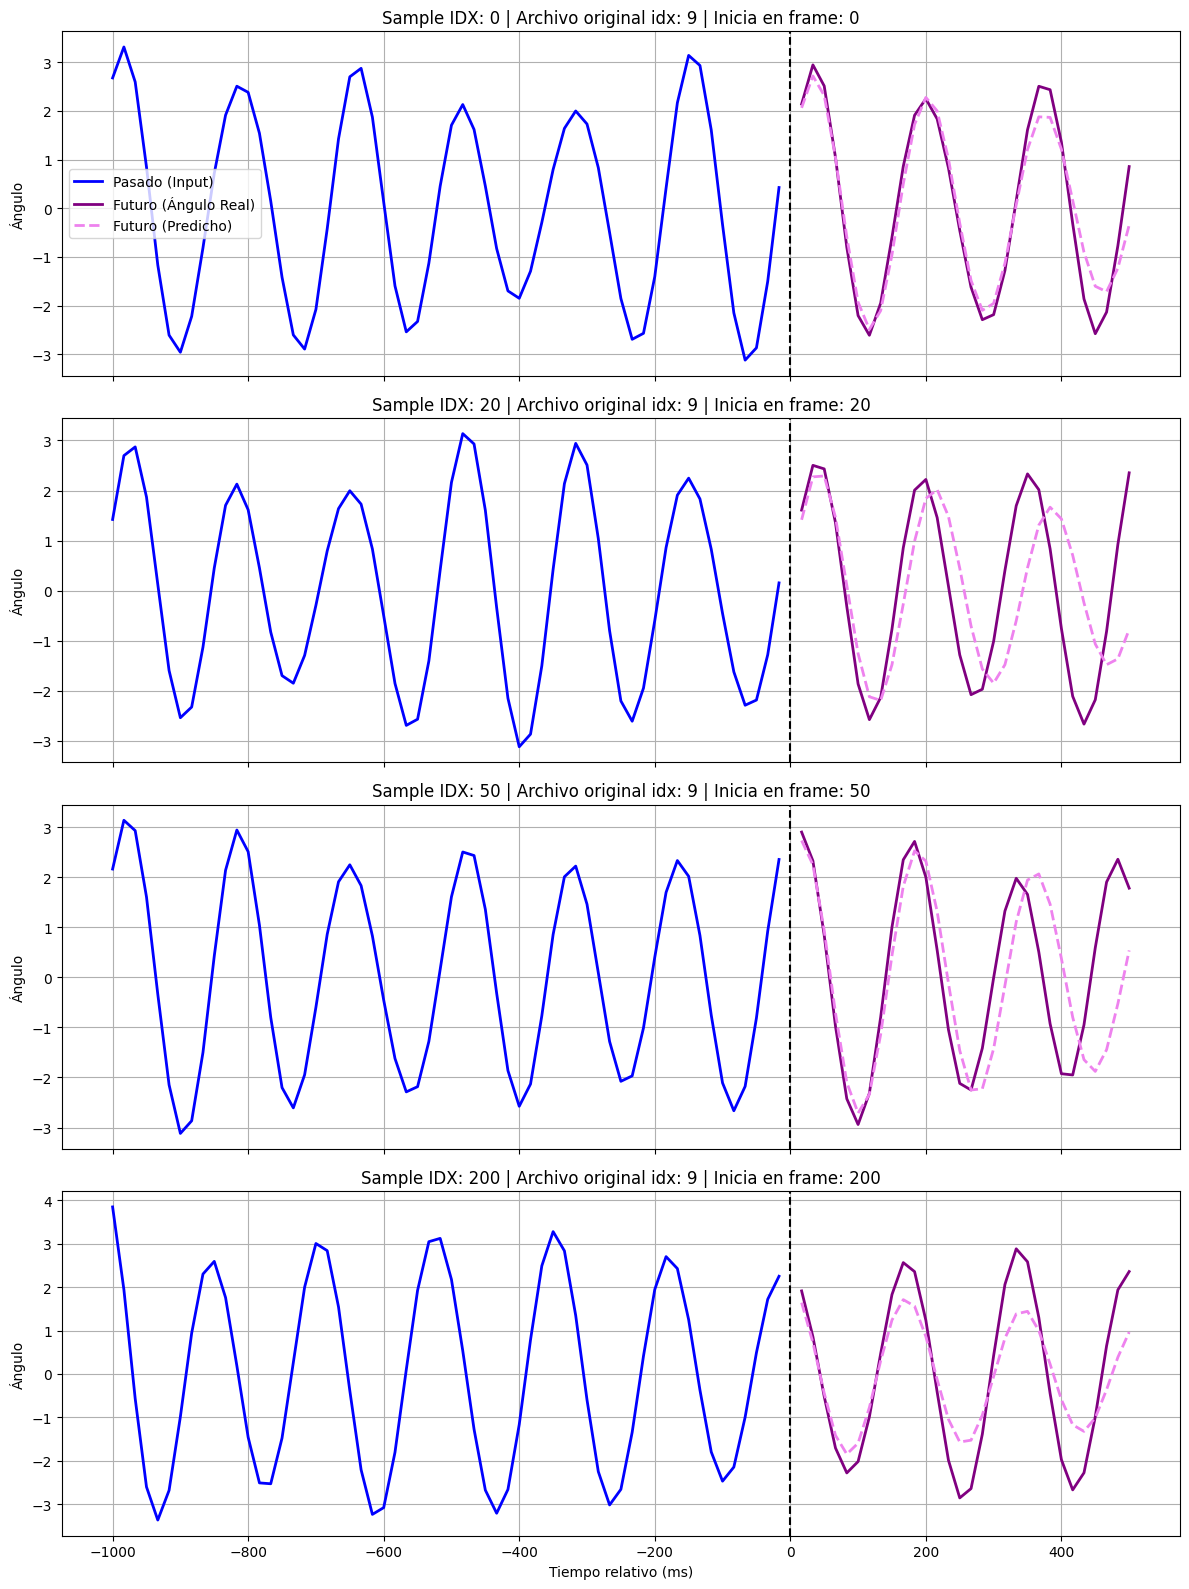

C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes\20260423_subject_01_cond_ASS-PRE-EXT-LEFT_run04_ecr_fcr_final_recortado.csv
raw: 3600
usable: 3040
expected y_pred len: 2951
actual y_pred len: 5542


In [ ]:
#esta funcion es para plotear varios ejemplos y ver la prediccion del test

def plot_multiple_continuous_examples(sample_indices, input_seconds=1.0, output_seconds=0.5):
    fs = 60  # Hz

    input_n = int(input_seconds * fs)
    output_n = int(output_seconds * fs)
    input_n = min(input_n, input_len)
    output_n = min(output_n, output_len)

    num_plots = len(sample_indices)
    
    fig, axes = plt.subplots(num_plots, 1, figsize=(12, 4 * num_plots), sharex=True)
    
    if num_plots == 1:
        axes = [axes]

    for i, sample_idx in enumerate(sample_indices):
        ax = axes[i]
        
        signal_idx, start_idx = meta_test[sample_idx]

        full_input = input_signals[signal_idx][80:]
        full_input_window = full_input[start_idx:start_idx + input_len + output_len]
        input_real = full_input_window[:input_len].flatten()

        pred_angle = scaler_output.inverse_transform(y_pred_test[sample_idx].reshape(-1, 1)).flatten()
        true_angle = scaler_output.inverse_transform(y_true_test[sample_idx].reshape(-1, 1)).flatten()

        t_input = np.arange(-input_n, 0) * (1000 / fs)
        t_output = np.arange(1, output_n + 1) * (1000 / fs)

        ax.plot(t_input, input_real[-input_n:], color="blue", linewidth=2, label="Pasado (Input)")
        ax.plot(t_output, true_angle[:output_n], color="purple", linewidth=2, label="Futuro (Ángulo Real)")
        ax.plot(t_output, pred_angle[:output_n], color="violet", linewidth=2, linestyle="--", label="Futuro (Predicho)")
        ax.axvline(0, color="black", linestyle="--", linewidth=1.5)

        ax.set_title(f"Sample IDX: {sample_idx} | Archivo original idx: {signal_idx} | Inicia en frame: {start_idx}")
        ax.set_ylabel("Ángulo")
        ax.grid(True)
        
        if i == 0:
            ax.legend(loc="best")

    axes[-1].set_xlabel("Tiempo relativo (ms)")
    
    plt.tight_layout()
    plt.show()

print("len(meta_test):", len(meta_test))
print("len(y_pred_test):", len(y_pred_test))
print("len(y_true_test):", len(y_true_test))
plot_multiple_continuous_examples(sample_indices=[0, 20, 50, 200], input_seconds=1.0, output_seconds=0.5)



### Error per time step

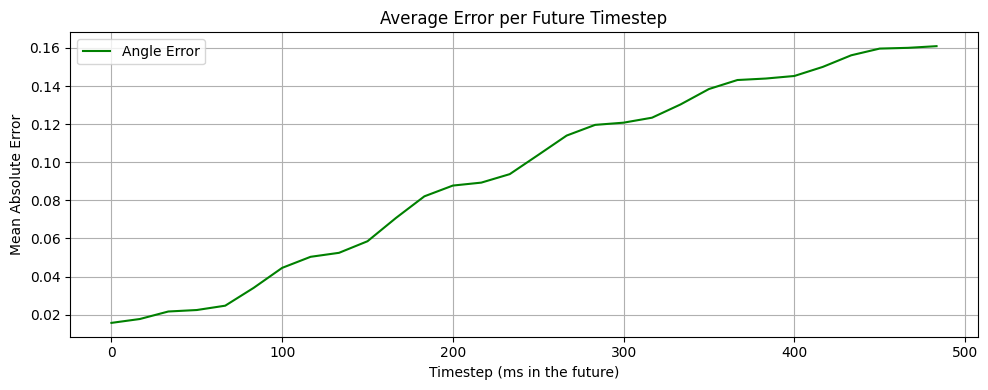

In [ ]:

errors = np.abs(y_pred_test - y_true_test)
mean_errors = errors.mean(axis=0)

t = np.arange(output_len) * (1000 / 60) 

plt.figure(figsize=(10, 4))
plt.plot(t, mean_errors[:, 0], label="Angle Error", color='green')
plt.title("Average Error per Future Timestep")
plt.xlabel("Timestep (ms in the future)")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Debbuging

In [ ]:
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

print(f"y_train min: {y_train.min()}, max: {y_train.max()}")

print(f"Input scaler min: {scaler_input.data_min_}, max: {scaler_input.data_max_}")
print(f"Output scaler min: {scaler_output.data_min_}, max: {scaler_output.data_max_}")

y_pred_train, y_true_train = evaluate_and_plot(train_loader, "Train")

np.save("test_indices.npy", test_idx)
np.save("train_indices.npy", train_idx)
np.save("val_indices.npy", val_idx) 

### Test

In [16]:
#-------------TEST------------------
# Evaluate on test set
def evaluate(loader):
    model.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            all_preds.append(pred.cpu().numpy())
            all_trues.append(y_batch.cpu().numpy())
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_trues)
    return y_pred, y_true

y_pred_test, y_true_test = evaluate(test_loader)


### Errores y mae

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt



def plot_error_analysis(y_pred, y_true, title="Test"):
    """
    1. Grafica el MAE por cada paso de tiempo futuro (Ángulo).
    2. Grafica la distribución del error (μ ± σ).
    """

    t = np.arange(output_len) # 60Hz

    #  1. Error absoluto medio (MAE) por timestep 
    errors_mae = np.abs(y_pred - y_true)
    mean_errors = errors_mae.mean(axis=0)

    plt.figure(figsize=(10, 4))
    plt.plot(t, mean_errors[:, 0], label="Angle Error", color='green')
    plt.title(f"Average Error per Future Timestep ({title})")
    plt.xlabel("Timestep")
    plt.ylabel("Mean Absolute Error (Degrees)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 2. Distribución del error (Media y Desviación Estándar)
    errors_raw = y_pred - y_true
    mu = errors_raw.mean(axis=0)   
    sigma = errors_raw.std(axis=0) 

    plt.figure(figsize=(10, 4))
    plt.plot(t, mu[:, 0], label="μ Angle", color='darkgreen')
    plt.fill_between(t, mu[:, 0] - sigma[:, 0], mu[:, 0] + sigma[:, 0], alpha=0.2, color='green', label="μ ± σ")
    plt.xlabel("Timestep")
    plt.ylabel("Error")
    plt.legend(loc="upper right", fontsize=10, frameon=True)
    plt.grid(False)
    plt.tight_layout()
    plt.show()


def plot_input_output_pair(X_subset, y_pred, y_true, index=0, title="Test"):
    """
    Grafica la secuencia del ángulo cinemático de entrada (pasado) frente a la predicción (futuro)
    """
    flat_pred = y_pred.reshape(-1, 1)
    flat_true = y_true.reshape(-1, 1)
    
    pred_inv = scaler_output.inverse_transform(flat_pred)
    true_inv = scaler_output.inverse_transform(flat_true)
    
    pred_inv_reshaped = pred_inv.reshape(-1, output_len, 1)
    true_inv_reshaped = true_inv.reshape(-1, output_len, 1)

    input_raw = X_subset[index]
    input_real = scaler_input.inverse_transform(input_raw.reshape(-1, 1)).flatten()

    pred_angle = pred_inv_reshaped[index]
    real_angle = true_inv_reshaped[index]

    input_len = len(input_real)
    t_input = np.arange(-input_len, 0) * (1000 / 60)  # Tiempo pasado
    t_output = np.arange(0, output_len) * (1000 / 60) # Tiempo futuro

    plt.figure(figsize=(10, 5))
    plt.plot(t_input, input_real, color='blue', label='Input Angles', linewidth=1.5)
    plt.plot(t_output, real_angle[:, 0], color='lightgreen', label='Real Angles', alpha=0.7)
    plt.plot(t_output, pred_angle[:, 0], color='darkgreen', linestyle='--', label='Predicted Angles')
    
    plt.xlabel("Time (ms)")
    plt.ylabel("Wrist Angles (Degrees)")
    plt.legend(loc="upper right")
    plt.grid(False)
    plt.tight_layout()
    plt.show()


📊 Test Prediction (NORMALIZED):
MAE: 0.0945, RMSE: 0.1334, R²: 0.6418
Correlation (normalized) Angle: 0.8011

📊 Test Angle Prediction:
MAE: 0.9391, RMSE: 1.3252, R²: 0.6418
Correlation (normalized) Angle: 0.8011


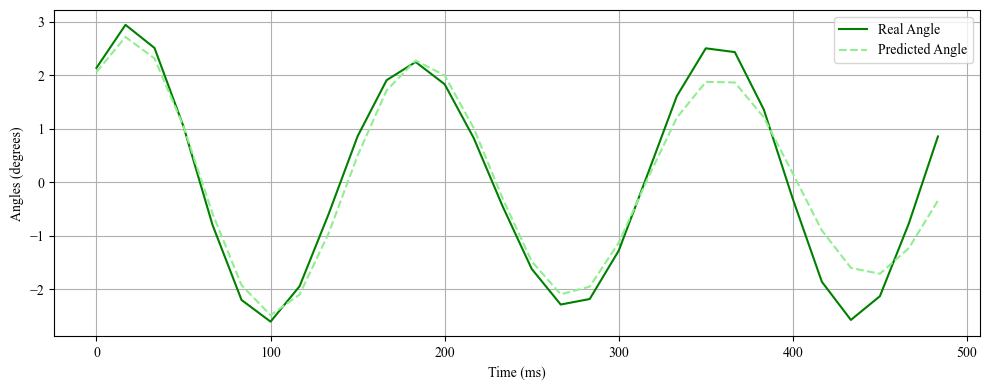

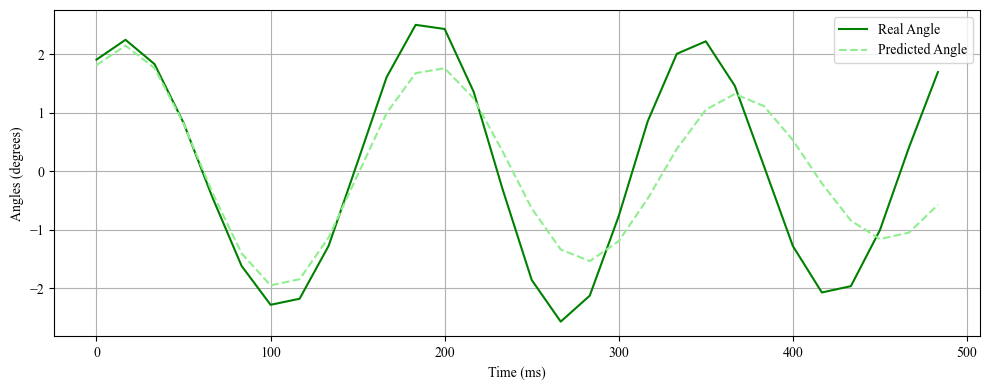

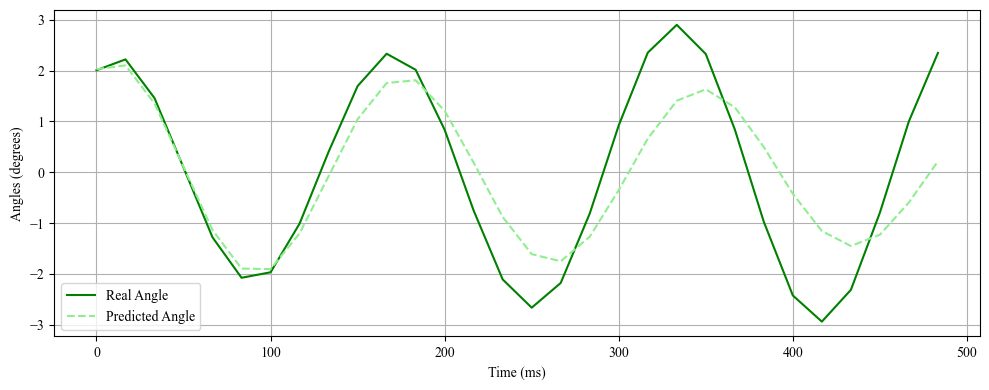

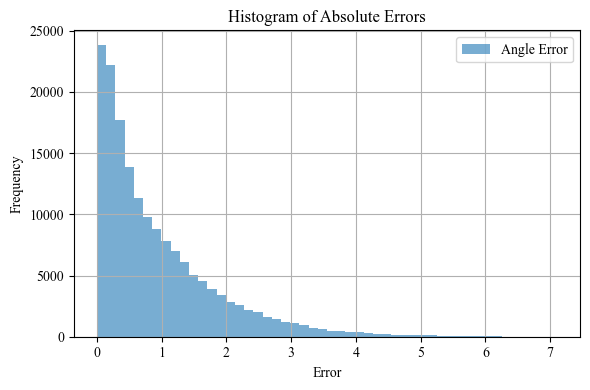

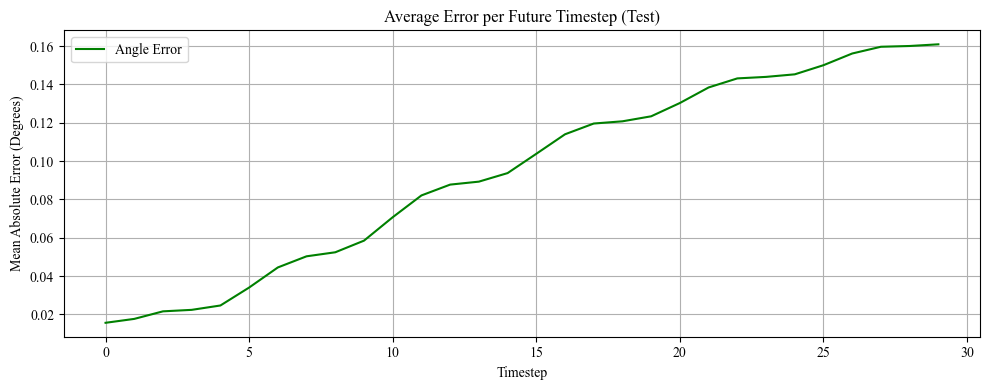

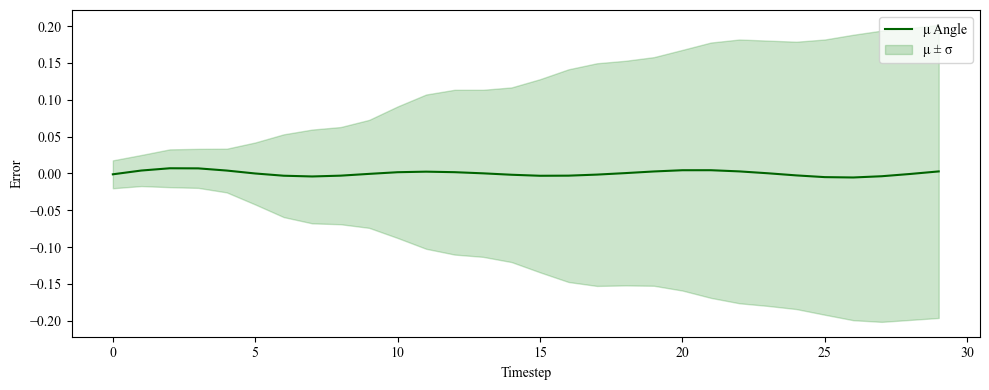

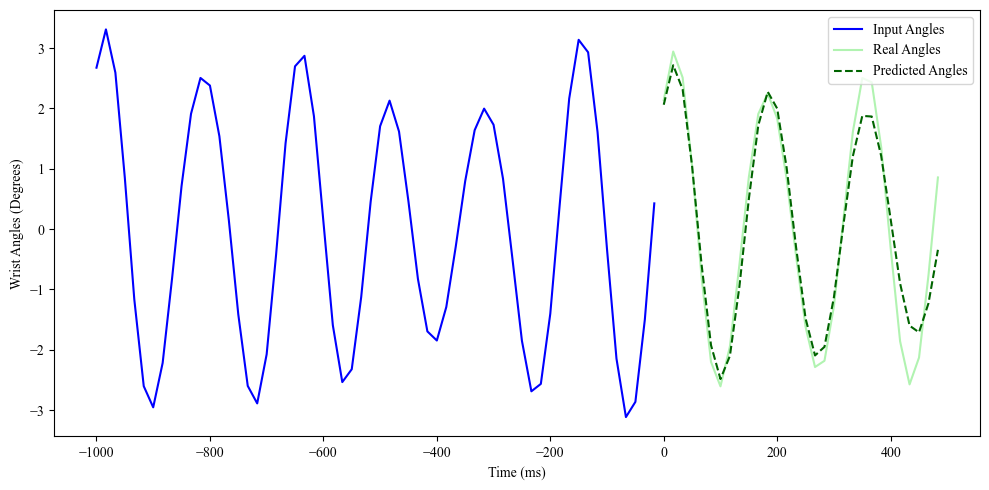

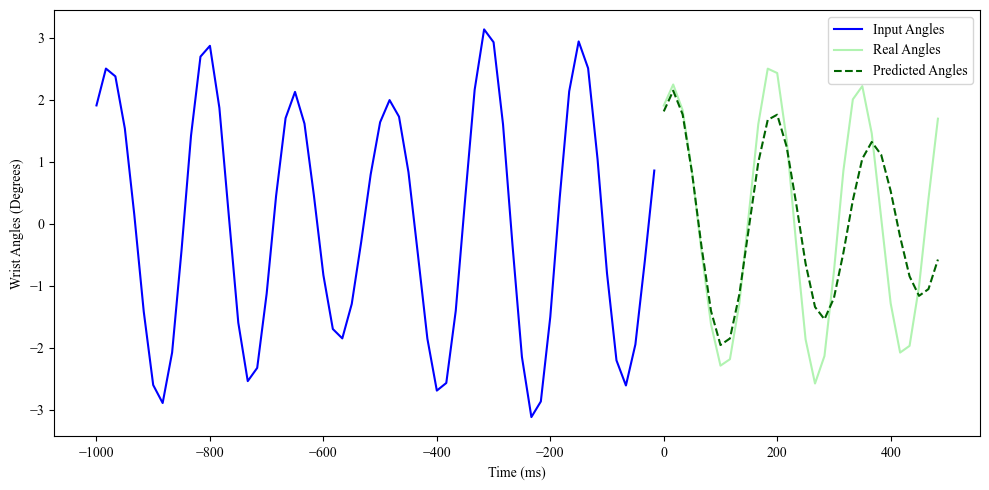

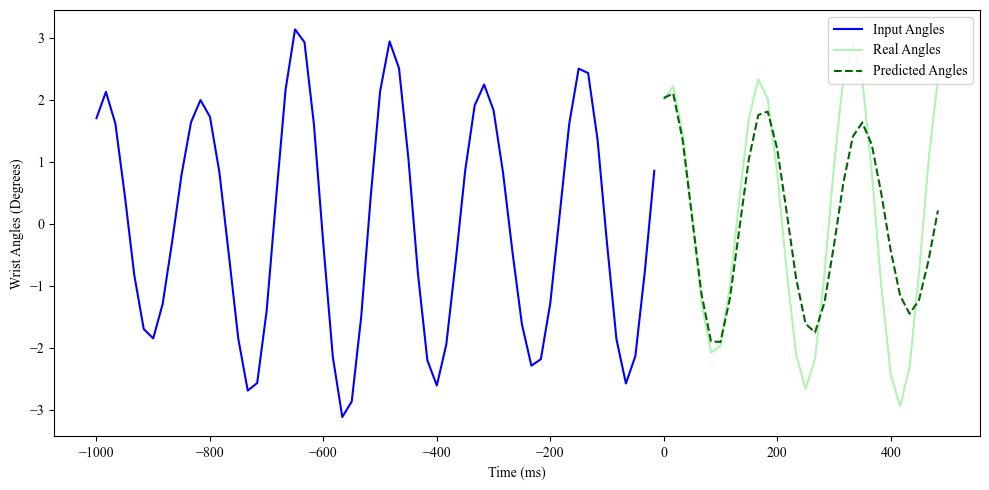

In [26]:
# Para Test
y_pred_test, y_true_test = evaluate_and_plot(test_loader, "Test") 
plot_error_analysis(y_pred_test, y_true_test, title="Test")
for idx in [0, 10, 30]:
    plot_input_output_pair(X_test, y_pred_test, y_true_test, index=idx, title="Test")

In [19]:
#Save predictions for later analysis/plotting
np.save(os.path.join(RESULTS_DIR, f"y_pred_test_{name}.npy"), y_pred_test)
np.save(os.path.join(RESULTS_DIR, f"y_true_test_{name}.npy"), y_true_test)

settings = {
    "batch_size": batch_size,
    "optimizer": "Adam",
    "learning_rate": 0.0005,# or your variable if it's not hardcoded
    "num_layers": 1,       # or your variable
    "dropout":  0.4987957571016527,  # or your variable
    "hidden_dim":35,      # or your variable
    "input_len": input_len,
    "output_len": output_len,
    "epochs": 120,
    "patience": patience,
    "seed": 42
}

with open(os.path.join(RESULTS_DIR, f"settings_{name}.json"), "w") as f:
    json.dump(settings, f, indent=4)

np.save(os.path.join(RESULTS_DIR, f"test_indices_{name}.npy"), test_idx)
np.save(os.path.join(RESULTS_DIR, f"train_indices_{name}.npy"), train_idx)
np.save(os.path.join(RESULTS_DIR, f"val_indices_{name}.npy"), val_idx)
